## Run model

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from xgboost import XGBClassifier

from sklearn.base import clone
import shap
import seaborn as sns

import matplotlib.pyplot as plt


In [2]:
def load_data(filepath, features, target):
    gdf = gpd.read_file(filepath)
    gdf = gdf.dropna()
    # gdf['population'] = np.log(gdf['population'])
    return gdf[features], gdf[target]

def scale_and_split(X, y, test_size=0.2, random_state=42):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, stratify=y, test_size=test_size, random_state=random_state
    )
    return pd.DataFrame(X_train, columns=X.columns), pd.DataFrame(X_test, columns=X.columns), y_train, y_test

def evaluate_model(model, X_test, y_test, selected_features=None):
    X_eval = X_test[selected_features] if selected_features is not None else X_test
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_test, y_pred)
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_test, y_pred, digits=3))
    return acc, y_pred

def run_lasso(X_train, y_train):
    model = LogisticRegressionCV(
        cv=StratifiedKFold(5),
        penalty='l1',
        solver='liblinear',
        scoring='accuracy',
        max_iter=1000,
        Cs=np.logspace(-4, 4, 20),
    )
    model.fit(X_train, y_train)
    return model

def run_rfecv(model, X_train, y_train, cv_splits=5):
    rfecv = RFECV(
        estimator=model,
        step=1,
        cv=StratifiedKFold(cv_splits),
        scoring='accuracy',
        n_jobs=-1
    )
    rfecv.fit(X_train, y_train)
    mask = rfecv.support_
    selected_vars = np.array(X_vars)[mask]

    # importâncias do estimador final (treinado só com as selecionadas)
    importances = rfecv.estimator_.feature_importances_

    # monta dict correto: soma deve ser ~1.0
    selected = dict(zip(selected_vars, importances))

    # print(f"Selecionadas: {rfecv.n_features_}/{X.shape[1]}")
    # print(pd.Series(selected).sort_values(ascending=False))

    return rfecv, selected

def run_sfs(model, X_train, y_train, cv_splits=5):
    sfs = SequentialFeatureSelector(
        model,
        direction='forward',
        scoring='accuracy',
        cv=StratifiedKFold(cv_splits),
        n_features_to_select='auto',
        n_jobs=-1
    )
    sfs.fit(X_train, y_train)
    mask = sfs.get_support()
    selected_vars = np.array(X_vars)[mask]

    # 2) Re-treina o modelo APENAS com as features selecionadas
    X_sel = X.loc[:, selected_vars] if hasattr(X, "loc") else X[:, mask]
    est = clone(model).fit(X_sel, y)

    # 3) Extrai importâncias/coefs do modelo re-treinado
    if hasattr(est, "feature_importances_"):
        vals = est.feature_importances_
    elif hasattr(est, "coef_"):
        # para regressão linear, pegar módulo ajuda a comparar magnitude
        vals = np.abs(np.ravel(est.coef_))
    else:
        vals = [None] * len(selected_vars)

    selected = dict(zip(selected_vars, vals))
    return sfs, selected

def save_model(model, name):
    os.makedirs("../../dataset/models", exist_ok=True)
    joblib.dump(model, f"../../dataset/models/predict_{name}.pkl")

In [3]:
shapefile_path = '../../dataset/shp/clusters.shp'
X_vars = [
    'age_index', 'median_age', 'sex_ratio', 'literate',
    'race_wht', 'race_blk', 'race_ylw', 'race_brn', 'race_ind', 'race_unk',
    'depriv_idx', 'wtr_area', 'veg_area', 'risk_area', 'slope_10',
    'slope_20', 'slope_30', 'slope_30p', 'hand_6p', 'hand_3_6', 'hand_0_3',
    'SO2', 'CO', 'O3', 'NO2', 'waste_coll', 'est_dens',
    'est_edu', 'est_health', 'est_relig', 'est_agri', 'est_other', 'est_const',
    'intra_veg', 'prim_hosp', 'inp_hosp'
]
target = 'cluster_3'

In [4]:
X, y = load_data(shapefile_path, X_vars, target)
X_train, X_test, y_train, y_test = scale_and_split(X, y)

results = []

### Lasso regression

In [11]:
print("\n=== Lasso Logistic Regression ===")
lasso_clf = run_lasso(X_train, y_train)
acc, _ = evaluate_model(lasso_clf, X_test, y_test)
save_model(lasso_clf, "lasso_cluster3")

# Variáveis selecionadas
for i, label in enumerate(lasso_clf.classes_):
    coefs = lasso_clf.coef_[i]
    selected_vars = [var for var, coef in zip(X.columns, coefs) if coef != 0]
    print(f"\nCluster {label} - Variáveis selecionadas ({len(selected_vars)}): {selected_vars}")
results.append(["LassoCV", acc, len(selected_vars), selected_vars])



=== Lasso Logistic Regression ===
Acurácia: 0.6488
              precision    recall  f1-score   support

           0      0.704     0.853     0.771      1176
           1      0.562     0.539     0.550       842
           2      0.529     0.127     0.205       283

    accuracy                          0.649      2301
   macro avg      0.598     0.506     0.509      2301
weighted avg      0.630     0.649     0.621      2301


Cluster 0 - Variáveis selecionadas (33): ['age_index', 'median_age', 'sex_ratio', 'literate', 'race_blk', 'race_ylw', 'race_brn', 'race_ind', 'race_unk', 'depriv_idx', 'wtr_area', 'veg_area', 'risk_area', 'slope_10', 'slope_30', 'slope_30p', 'hand_6p', 'hand_0_3', 'SO2', 'CO', 'O3', 'NO2', 'waste_coll', 'est_dens', 'est_edu', 'est_health', 'est_relig', 'est_agri', 'est_other', 'est_const', 'intra_veg', 'prim_hosp', 'inp_hosp']

Cluster 1 - Variáveis selecionadas (36): ['age_index', 'median_age', 'sex_ratio', 'literate', 'race_wht', 'race_blk', 'race_ylw', 'rac

### Radom Forest with RFECV

In [5]:
print("\n=== Random Forest com RFECV ===")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rfecv_rf, selected_rf = run_rfecv(rf_model, X_train, y_train)
features = list(selected_rf.keys())
rf_model.fit(X_train[features], y_train)
acc, _ = evaluate_model(rf_model, X_test, y_test, features)
save_model(rfecv_rf, "rfecv_rf_cluster3")
results.append(["RFECV_RF", acc, len(selected_rf), selected_rf])


=== Random Forest com RFECV ===
Acurácia: 0.7162
              precision    recall  f1-score   support

           0      0.761     0.873     0.813      1176
           1      0.646     0.615     0.630       842
           2      0.687     0.364     0.476       283

    accuracy                          0.716      2301
   macro avg      0.698     0.617     0.640      2301
weighted avg      0.710     0.716     0.705      2301



### Random Forest with Sequential Feature Selection

In [13]:
print("\n=== Random Forest com SFS ===")
rf_sfs_model = RandomForestClassifier(n_estimators=200, random_state=42)
sfs_rf, selected_sfs_rf = run_sfs(rf_sfs_model, X_train, y_train)
features = list(selected_sfs_rf.keys())
rf_sfs_model.fit(X_train[features], y_train)
acc, _ = evaluate_model(rf_sfs_model, X_test, y_test, features)
save_model(sfs_rf, "sfs_rf_cluster3")
results.append(["SFS_RF", acc, len(selected_sfs_rf), selected_sfs_rf])


=== Random Forest com SFS ===
Acurácia: 0.7158
              precision    recall  f1-score   support

           0      0.750     0.871     0.806      1176
           1      0.655     0.614     0.634       842
           2      0.721     0.375     0.493       283

    accuracy                          0.716      2301
   macro avg      0.709     0.620     0.644      2301
weighted avg      0.712     0.716     0.705      2301



Exception ignored in: <function ResourceTracker.__del__ at 0x106860e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1036ece00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versi

## exploration

In [6]:
results_df = pd.DataFrame(results, columns=["Modelo", "Acurácia", "Qtd_Variáveis", "Variáveis_Selecionadas"])
# results_df.to_csv("../../dataset/models/resumo_classificacao_cluster_new.csv", index=False)
pd.set_option('display.max_colwidth', None)
print("\nResumo final:")
results_df


Resumo final:


,Modelo,Acurácia,Qtd_Variáveis,Variáveis_Selecionadas
0,RFECV_RF,0.71621,15,"{'age_index': 0.07733356270658302, 'literate': 0.05491060761806997, 'race_wht': 0.049822235116139486, 'race_brn': 0.055761604278321206, 'depriv_idx': 0.10989430975672648, 'slope_10': 0.058637152647829184, 'hand_0_3': 0.05363657807239077, 'SO2': 0.05384186317189325, 'CO': 0.07527316037037798, 'O3': 0.07371683917722172, 'NO2': 0.09440647358065857, 'waste_coll': 0.05633595225767351, 'est_dens': 0.07042599153579596, 'prim_hosp': 0.055337611564782445, 'inp_hosp': 0.06066605814553633}"


In [7]:
explainer = shap.TreeExplainer(rf_model)
features = list(selected_rf.keys())
sv = explainer.shap_values(X_test[features])
# np.save("../../dataset/models/shap_values_rf_cluster.npy", sv)

Exception ignored in: <function ResourceTracker.__del__ at 0x103ef0e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102d98e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versi

In [8]:
features

[np.str_('age_index'),
 np.str_('literate'),
 np.str_('race_wht'),
 np.str_('race_brn'),
 np.str_('depriv_idx'),
 np.str_('slope_10'),
 np.str_('hand_0_3'),
 np.str_('SO2'),
 np.str_('CO'),
 np.str_('O3'),
 np.str_('NO2'),
 np.str_('waste_coll'),
 np.str_('est_dens'),
 np.str_('prim_hosp'),
 np.str_('inp_hosp')]

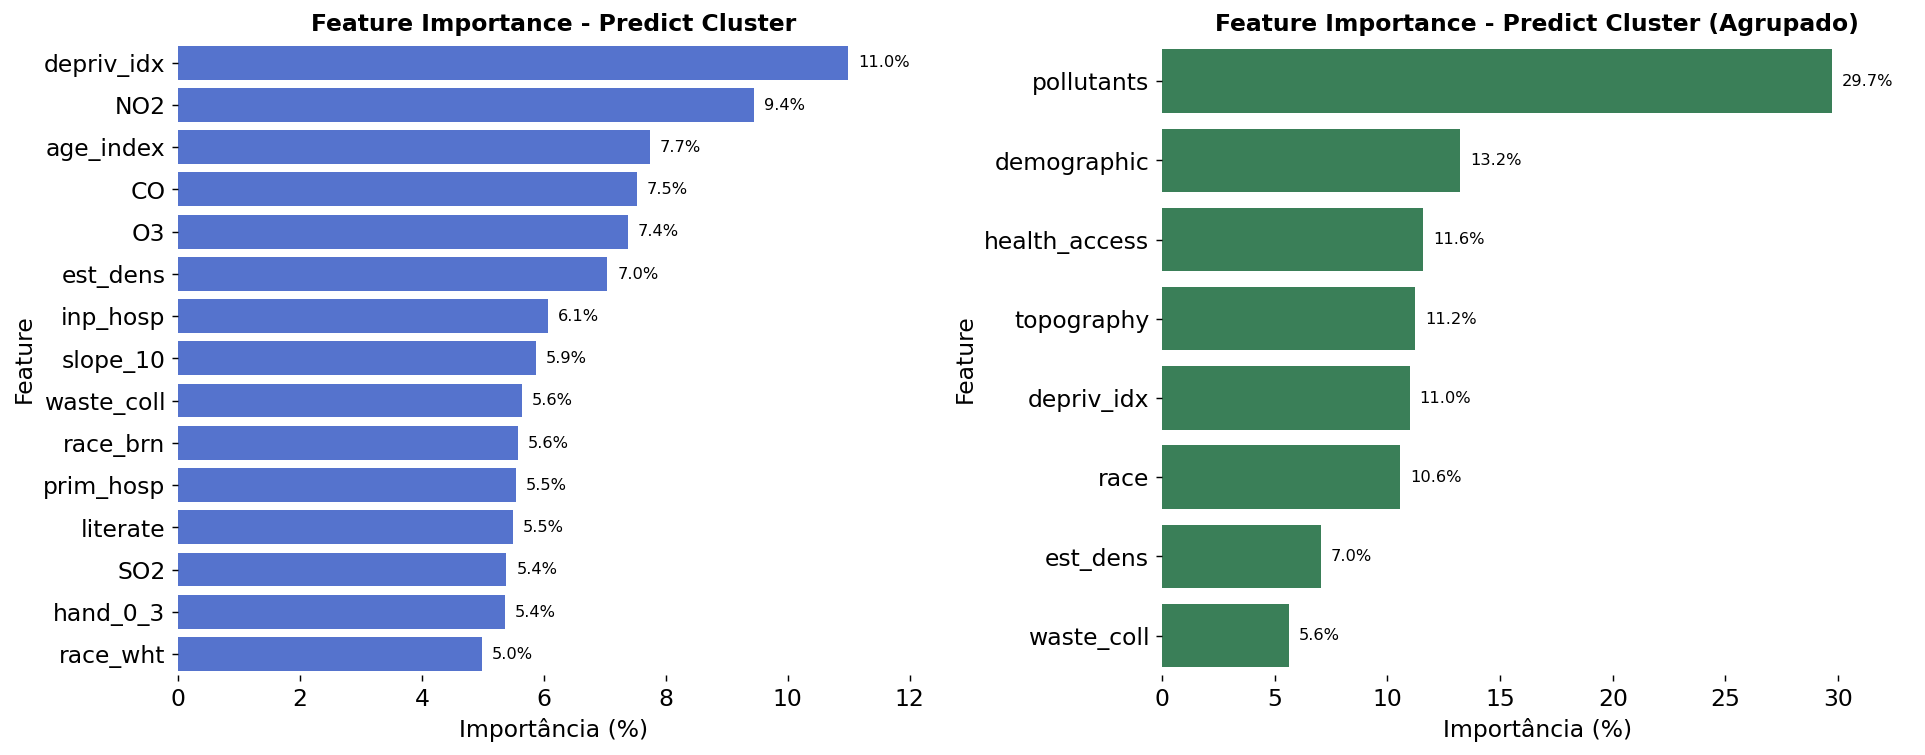

In [22]:
fi_cluster = {'age_index': 0.07733356270658302, 'literate': 0.05491060761806997, 'race_wht': 0.049822235116139486, 'race_brn': 0.055761604278321206, 'depriv_idx': 0.10989430975672648, 'slope_10': 0.058637152647829184, 'hand_0_3': 0.05363657807239077, 'SO2': 0.05384186317189325, 'CO': 0.07527316037037798, 'O3': 0.07371683917722172, 'NO2': 0.09440647358065857, 'waste_coll': 0.05633595225767351, 'est_dens': 0.07042599153579596, 'prim_hosp': 0.055337611564782445, 'inp_hosp': 0.06066605814553633}

def dict_to_df(d, sort_desc=True):
    df = pd.DataFrame(list(d.items()), columns=["Feature", "Importance"])
    df["Importance_pct"] = df["Importance"] * 100
    df = df.sort_values("Importance_pct", ascending=not sort_desc).reset_index(drop=True)
    return df

def plot_hbar_with_labels(ax, df, title, color="royalblue"):
    sns.barplot(data=df, x="Importance_pct", y="Feature", color=color, ax=ax)
    for i, val in enumerate(df["Importance_pct"]):
        ax.text(val + df["Importance_pct"].max()*0.015, i, f"{val:.1f}%",
                va="center", fontsize=9)
    ax.set_xlabel("Importância (%)")
    ax.set_ylabel("Feature")
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlim(0, df["Importance_pct"].max() * 1.12)
    sns.despine(ax=ax, left=True, bottom=True)

def group_features(fi: dict):
    fi = fi.copy()
    pollutant_keys = ['CO', 'NO2', 'O3', 'SO2']
    health_access_keys = ['prim_hosp', 'inp_hosp']
    topography_keys = ['slope_10', 'hand_0_3']
    race_keys = ['race_wht', 'race_brn']
    demographic_keys = ['age_index', 'literate']

    pollutants_sum = sum(fi[k] for k in pollutant_keys)
    health_access_sum = sum(fi[k] for k in health_access_keys)
    topography_sum = sum(fi[k] for k in topography_keys)
    race_sum = sum(fi[k] for k in race_keys)
    demographic_sum = sum(fi[k] for k in demographic_keys)
    for k in pollutant_keys + health_access_keys + topography_keys + race_keys + demographic_keys:
        fi.pop(k, None)

    fi['pollutants'] = pollutants_sum
    fi['health_access'] = health_access_sum
    fi['topography'] = topography_sum
    fi['race'] = race_sum
    fi['demographic'] = demographic_sum
    return fi

# --- DataFrames ---
df_orig = dict_to_df(fi_cluster, sort_desc=True)
df_group = dict_to_df(group_features(fi_cluster), sort_desc=True)

# --- plot lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
plot_hbar_with_labels(axes[0], df_orig, "Feature Importance - Predict Cluster", color="royalblue")
plot_hbar_with_labels(axes[1], df_group, "Feature Importance - Predict Cluster (Agrupado)", color="seagreen")
plt.tight_layout()
plt.show()






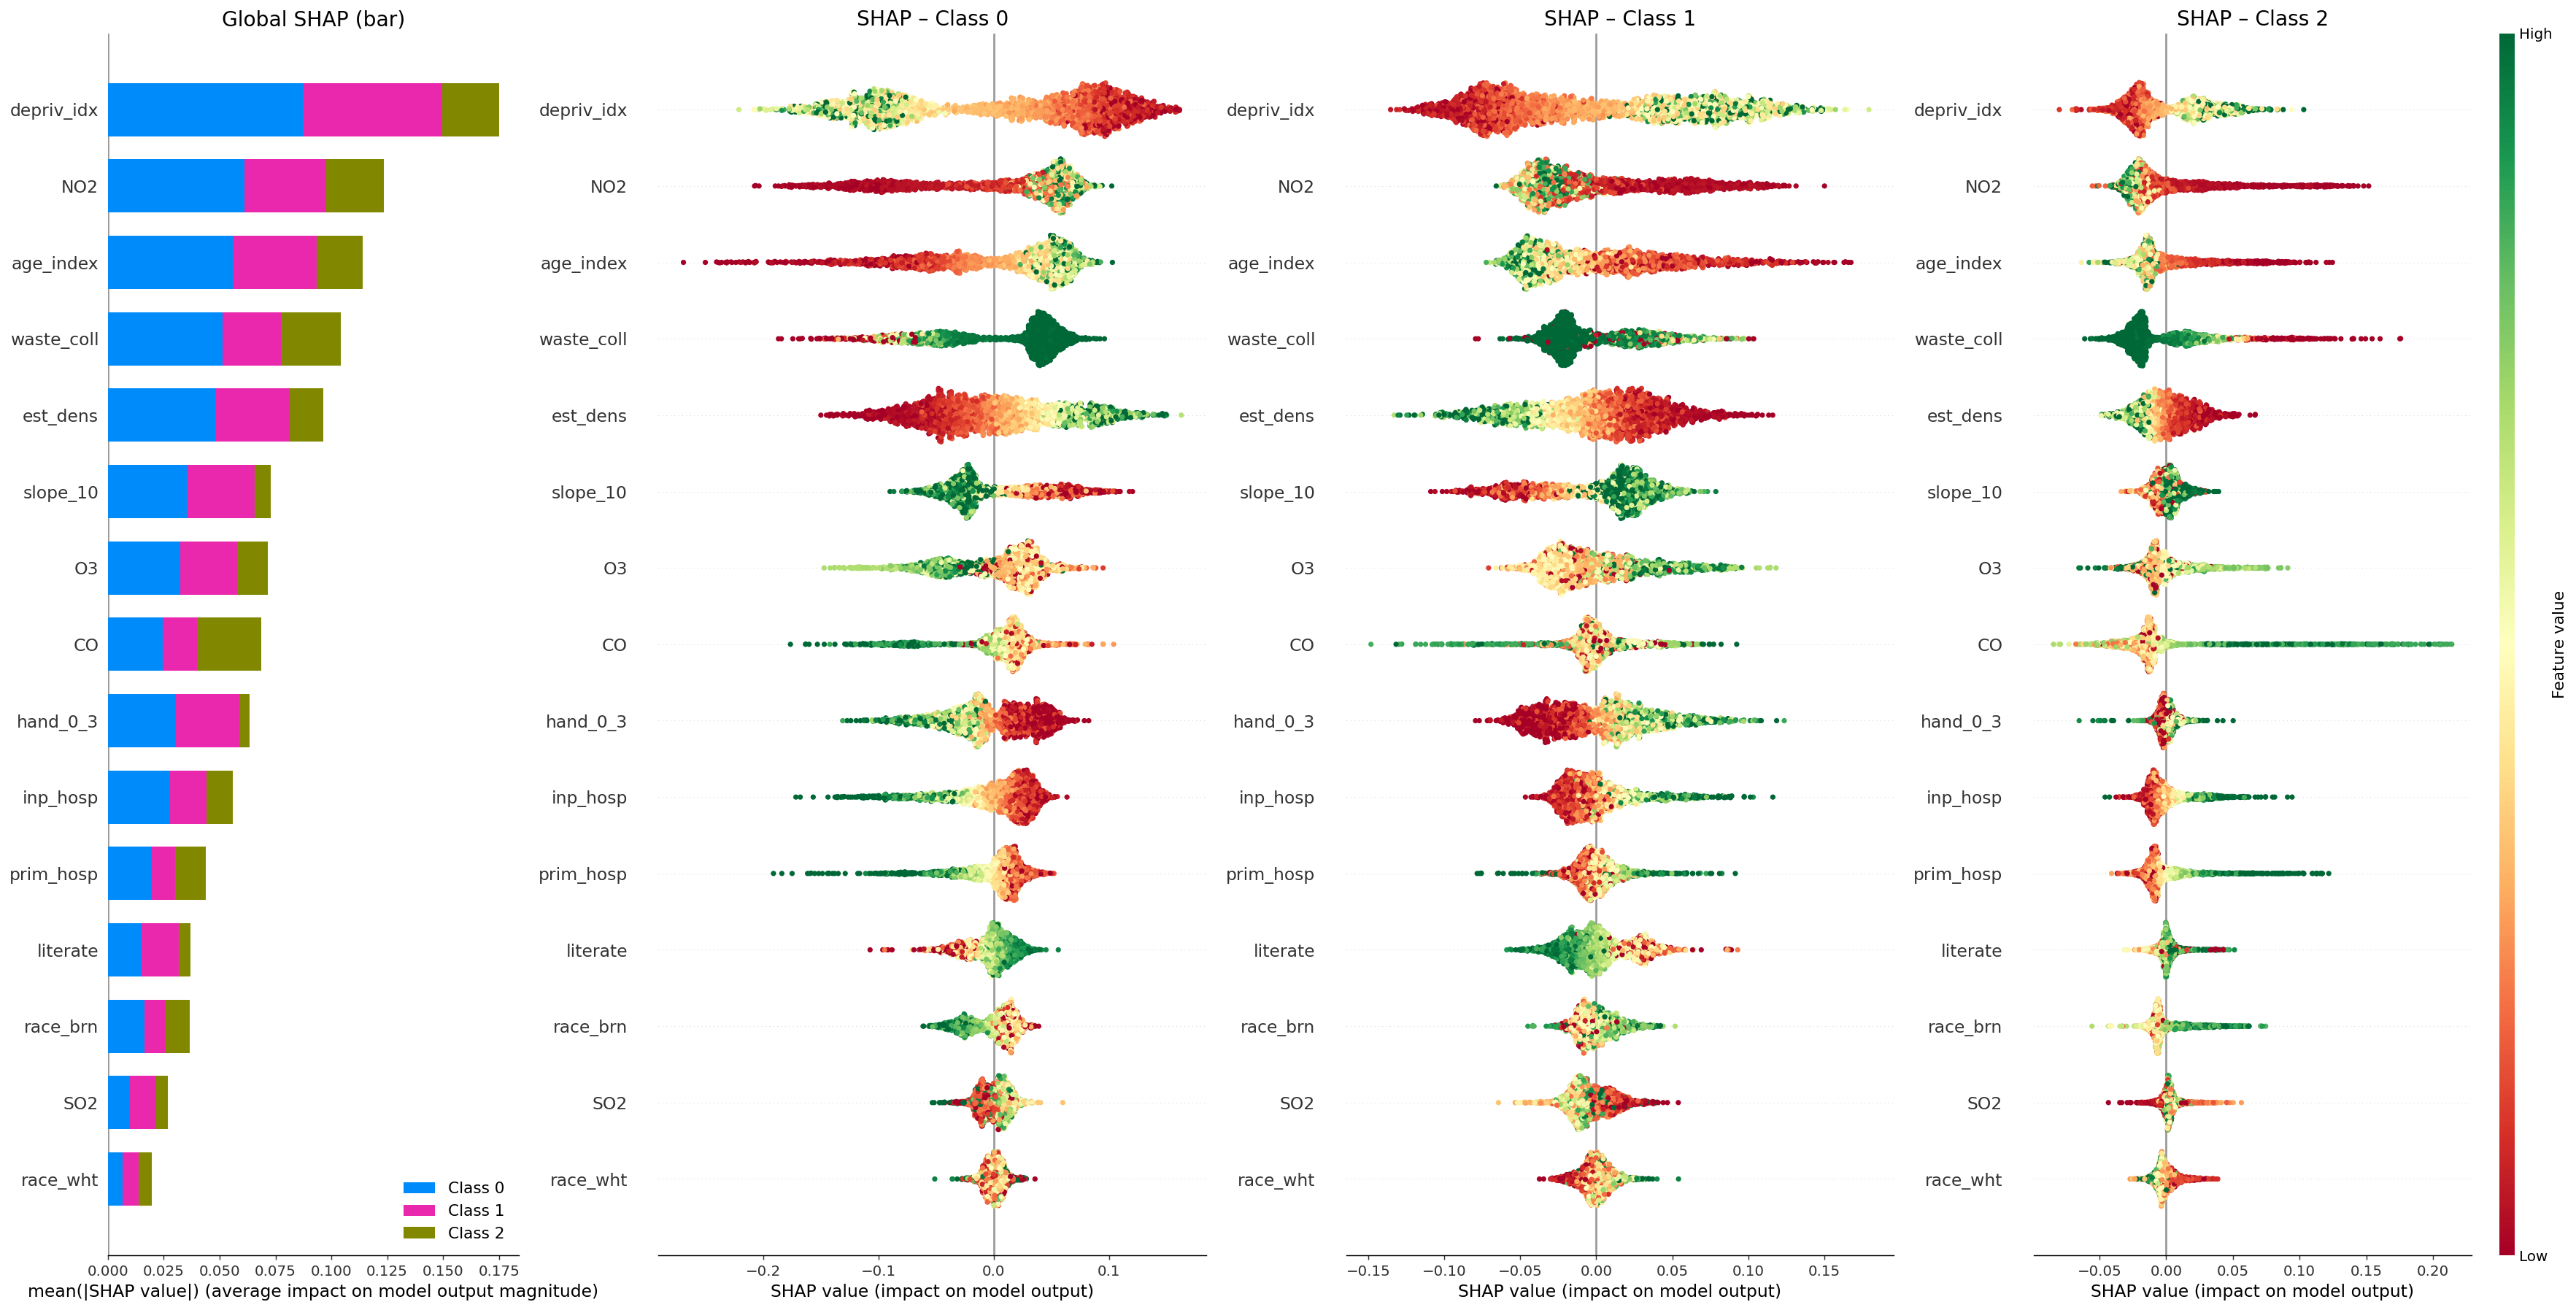

In [54]:
X_sel = X_test[features]  # subset e ordem pretendida
class_names = ["Class 0","Class 1","Class 2"]  # ajuste se quiser

# 1) Unificar sv para (n_amostras, n_features, n_classes)
if isinstance(sv, list):
    sv_arr = np.stack(sv, axis=-1)  # lista -> array 3D
else:
    sv_arr = sv

X_sel = X_test[features].copy()

# 2) ORDEM global por importância SHAP (mean |SHAP| somando classes)
glob_mean_abs = np.abs(sv_arr).mean(axis=(0, 2))          # (p,)
order_idx = np.argsort(glob_mean_abs)[::-1]               # desc
feat_order = [X_sel.columns[i] for i in order_idx]
X_ord = X_sel[feat_order]
sv_ord = sv_arr[:, order_idx, :]

# 3) Importância global em % (para barras bem longas)
glob_pct = 100 * glob_mean_abs[order_idx] / glob_mean_abs.sum()

# 4) FIGURA BEM GRANDE (largura e altura escaladas)
N = len(feat_order)
W = 50                             # MUITO largo
H = max(14, 0.70 * N)              # altura cresce com nº de features

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 13
})

fig, axes = plt.subplots(
    1, 4,
    figsize=(W, H),
    gridspec_kw={"width_ratios": [1.2, 1.6, 1.6, 1.6]}
)
# margens generosas p/ nomes longos e espaço entre painéis
plt.subplots_adjust(left=0.28, right=0.995, wspace=0.35)

plt.sca(axes[0])
shap.summary_plot(
    sv_ord, X_ord,
    plot_type="bar",
    sort=False,
    max_display=N,
    show=False,
    

)
axes[0].set_title("Global SHAP (bar)")

# (Painéis 2–4) Beeswarm por classe – mesma ordem
for k, nome in enumerate(class_names):
    ax = axes[k+1]
    plt.sca(ax)                 # selecione o axes ANTES

    shap.summary_plot(
        sv_ord[..., k],
        X_ord,
        plot_type="dot",
        sort=False,
        cmap="RdYlGn",
        max_display=N,
        color_bar=(k == len(class_names) - 1),  # <<< só no último
        show=False,
        plot_size=(W * 0.55, H) # ajuda o SHAP a “respeitar” o tamanho
    )
    ax.set_title(f"SHAP – {nome}")


plt.show()

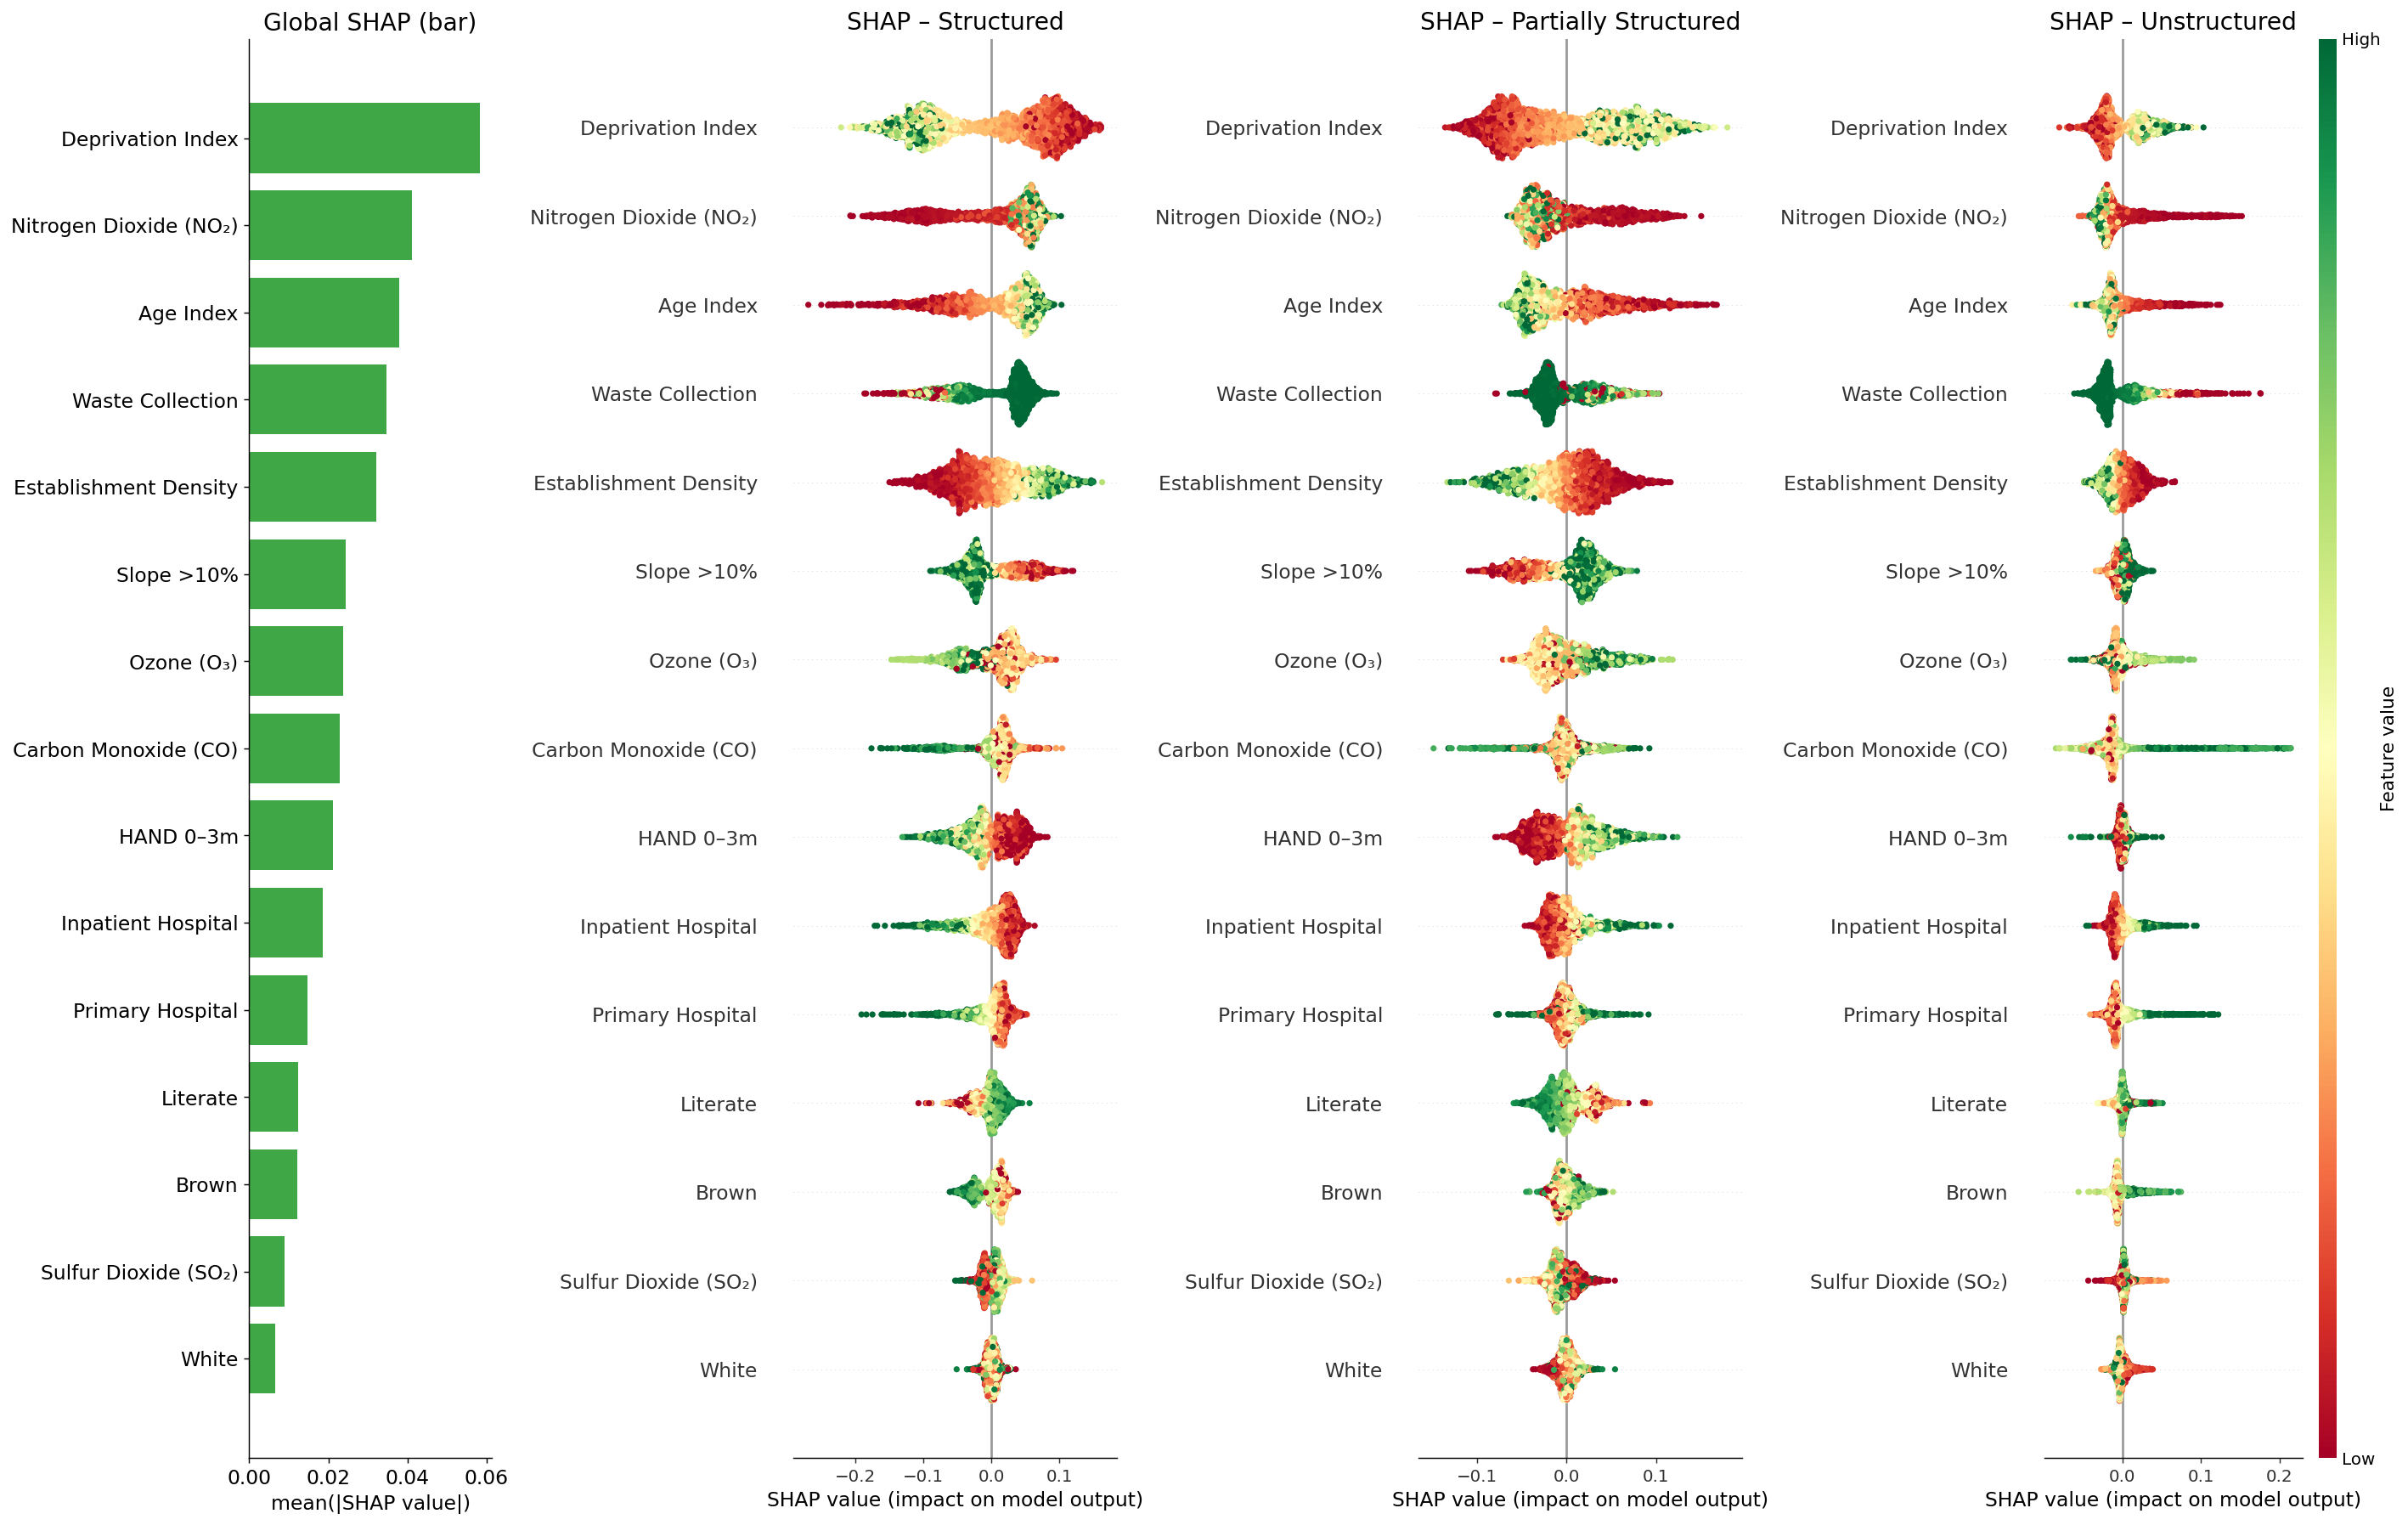

In [10]:
import matplotlib.pyplot as plt
import shap
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Paleta para os clusters
CLUSTER_COLORS = {
    0: "#3fa745",   # Structured
    1: "#fab800",   # Partially Structured
    2: "#dc3444"    # Unstructured
}

def build_cmap(hex_color):
    return LinearSegmentedColormap.from_list("custom", ["#ffffff", hex_color])

CLUSTER_CMAPS = {
    0: build_cmap(CLUSTER_COLORS[0]),
    1: build_cmap(CLUSTER_COLORS[1]),
    2: build_cmap(CLUSTER_COLORS[2]),
}

# --- Mapeamento para deixar os nomes das variáveis mais legíveis ---
FEATURE_NAME_MAPPING = {
    'age_index':        'Age Index',
    'literate':         'Literate',
    'race_wht':         'White',
    'race_brn':         'Brown',
    'race_unk':         'Unknown Race',
    'median_age':       'Median Age',
    'depriv_idx':       'Deprivation Index',
    'slope_10':         'Slope >10%',
    'hand_0_3':         'HAND 0–3m',
    'hand_6p':          'HAND >6m',
    'SO2':              'Sulfur Dioxide (SO₂)',
    'CO':               'Carbon Monoxide (CO)',
    'O3':               'Ozone (O₃)',
    'NO2':              'Nitrogen Dioxide (NO₂)',
    'waste_coll':       'Waste Collection',
    'est_dens':         'Establishment Density',
    'wtr_area':         'Water Area',
    'risk_area':        'Risk Area',
    'prim_hosp':        'Primary Hospital',
    'inp_hosp':         'Inpatient Hospital',
    # Adicione outros nomes conforme necessário
}

def prettify_feature_names(cols):
    """Converte uma lista de nomes de variáveis para nomes legíveis."""
    return [FEATURE_NAME_MAPPING.get(col, col.replace('_', ' ').title()) for col in cols]

# --- Preparação dos dados ---
X_selected = X_test[features].copy()

if isinstance(sv, list):
    shap_values_arr = np.stack(sv, axis=-1)  # (n, p, K)
else:
    shap_values_arr = sv

# ordem global de importância
global_mean_abs_shap = np.abs(shap_values_arr).mean(axis=(0, 2))   # (p,)
feature_sort_idx = np.argsort(global_mean_abs_shap)[::-1]
ordered_feature_names = [X_selected.columns[i] for i in feature_sort_idx]
pretty_feature_names = prettify_feature_names(ordered_feature_names)

X_ordered = X_selected[ordered_feature_names]
shap_values_ordered = shap_values_arr[:, feature_sort_idx, :]                   # reordena shap

n_features = len(ordered_feature_names)
fig_width = 40
fig_height = max(14, 0.70 * n_features)

plt.rcParams.update({"figure.dpi": 130, "font.size": 13})

fig, axes = plt.subplots(
    1, 4,
    figsize=(fig_width, fig_height),
    gridspec_kw={"width_ratios": [1.2, 1.6, 1.6, 1.6]}
)
plt.subplots_adjust(left=0.28, right=0.995, wspace=0.35)

# ------------------------------------------------------------------
# (a) Painel global de barras - feito manualmente em Matplotlib
# ------------------------------------------------------------------
ax0 = axes[0]

sorted_global_shap_vals = global_mean_abs_shap[feature_sort_idx]  # mesma ordem das features
bar_y_pos = np.arange(n_features)

ax0.barh(bar_y_pos, sorted_global_shap_vals, color=CLUSTER_COLORS[0])
ax0.set_yticks(bar_y_pos)
ax0.set_yticklabels(pretty_feature_names)
ax0.invert_yaxis()  # feature mais importante em cima
ax0.set_xlabel("mean(|SHAP value|)")
ax0.set_title("Global SHAP (bar)")

# Remove apenas as bordas superior e direita
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
# Deixa as bordas inferior e esquerda visíveis (eixo x/y)
ax0.spines['left'].set_visible(True)
ax0.spines['bottom'].set_visible(True)

# ------------------------------------------------------------------
# (b–d) Beeswarm por classe, com colormap customizado
# ------------------------------------------------------------------
CLUSTER_NAMES = ["Structured", "Partially Structured", "Unstructured"]

def build_cmap_dark(hex_color):
    return LinearSegmentedColormap.from_list(
        "custom",
        ["#444444", hex_color]   # cinza escuro → cor do cluster
    )

CLUSTER_CMAPS_DARK = {
    0: build_cmap_dark(CLUSTER_COLORS[0]),
    1: build_cmap_dark(CLUSTER_COLORS[1]),
    2: build_cmap_dark(CLUSTER_COLORS[2])
}

for class_idx, class_name in enumerate(CLUSTER_NAMES):
    ax = axes[class_idx+1]
    plt.sca(ax)

    # Usar nomes legíveis para as variáveis
    shap.summary_plot(
        shap_values_ordered[..., class_idx],
        X_ordered,
        plot_type="dot",
        sort=False,
        max_display=n_features,
        feature_names=pretty_feature_names,
        # cmap=CLUSTER_CMAPS_DARK[class_idx],               # gradiente na cor do cluster
        cmap="RdYlGn",
        color_bar=(class_idx == len(CLUSTER_NAMES) - 1), # barra só no último
        show=False,
        plot_size=(fig_width * 0.55, fig_height)
    )
    ax.set_title(f"SHAP – {class_name}")

plt.show()